# 1D Evolution

## Imports

In [1]:
# Important modules
import os
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Kinetic misalignment functions
from kin_mis_utils import (evolution_kinetic_mis, genspec_kinetic_mis)

# Run simulations
from pyaxions import simgen as sg

# Deal with measurement files from simulations
from pyaxions import jaxions as pa

## Axion Parameters

In [2]:
tautab = np.linspace(1, 5, 1000) # Normalized conformal time array, SHOULD START AT 1!

In [3]:
fAGeV = 1.14e+11 # Axion decay constant in GeV
theta1 = 0 # Initial field value of zero mode
vheta1 = 15 # Initial velocity value of zero mode

## 1D Evolution

In [4]:
result1D = evolution_kinetic_mis(fAGeV, theta1, vheta1, tautab)

In [5]:
theta1D = result1D['thetatab']
vheta1D = result1D['vhetatab']

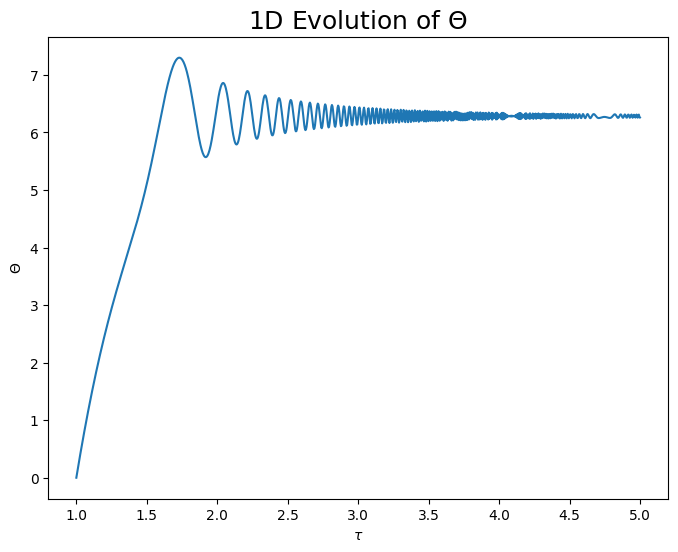

In [6]:
# Plot 1D evolution of θ
plt.figure(figsize = (8, 6))
plt.plot(tautab, theta1D)
plt.title(r"1D Evolution of $\Theta$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Theta$')
plt.show()

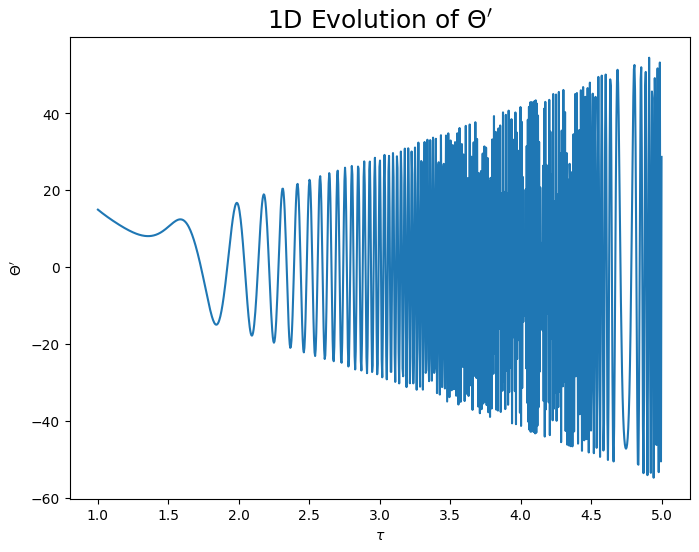

In [7]:
# Plot 1D evolution of θ'
plt.figure(figsize = (8, 6))
plt.plot(tautab, vheta1D)
plt.title(r"1D Evolution of $\Theta'$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Theta'$")
plt.show()

## Lattice Simulations

In [8]:
# Simulation parameters
N = 64 # Points/dimension
L = 3 # Box length in L₁ units
R = 1.0 # Scale factor in R₁ units, SHOULD BE 1!
msa = 1.0 # String resolution
tauf = 5.0 # End of simulation 

In [9]:
# Create initial conditions
genspec_kinetic_mis(N, L, R, theta1, vheta1, hom = True)
print('Initial conditions created.')

Initial conditions created.


In [10]:
# Run simulations
rank, jax = sg.simgen(N = N, L = L, msa = msa, zRANKS = 2, ctf = tauf, ic = 'spax', ict = 'spax', prec = 'single',
                      dev = 'cpu', lap = 2, fftplan = 64, fA = fAGeV, vqcd = 'vqcdC', xtr = ' --ftype axion --mode0 1',
                      cti = R, meas = 0, spKGV = 15, rmask = 4.0, p3D = 2, p2Dmap = True, p2DmapE = True, p2DmapPE = True, 
                      slc = N//2, nologmpi = True, verbose = 3, sIter = 5, verb = False, dump = 1)
    
sg.runsim(JAX = jax, RANK = rank, THR = 16//rank, USA = '', VERB = False, BONDEN = True)
    
os.system('mv axion.log.0 log-run.txt initialspectrum.dat out')



--------------------------------------------------------------------------------------------
Mode: run 

Overview: N=64, MPI_RANKS=2, L=3.000000, msa=1.000000

Done!
--------------------------------------------------------------------------------------------


0

In [11]:
# Load measurement file
path = os.getcwd()
file_path = "/out"
mf = pa.findmfiles(path +  file_path)

In [12]:
tautab_sim = pa.gml(mf, 'ct') # Conformal times 
R_sim = pa.gml(mf, 'R') # Scale factor in R1
theta_maps = pa.gml(mf, 'maptheta') # Field values
vheta_maps = (pa.gml(mf, 'mapvheta')-theta_maps)/R_sim[:, None, None] # Velocity w.r.t. conformal time

In [13]:
# Zero mode (average)
theta_avg = []  
vheta_avg = []

for i in np.arange(len(theta_maps)):
    theta_avg.append(np.mean(theta_maps[i]))
    vheta_avg.append(np.mean(vheta_maps[i]))
    
theta_avg = np.asarray(theta_avg)
vheta_avg = np.asarray(vheta_avg)

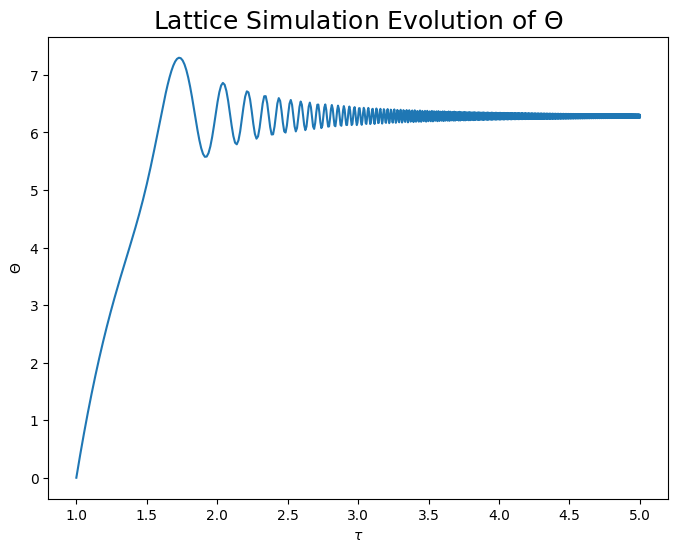

In [14]:
# Plot lattice simulation evolution of θ
plt.figure(figsize = (8, 6))
plt.plot(tautab_sim, theta_avg)
plt.title(r"Lattice Simulation Evolution of $\Theta$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Theta$')
plt.show()

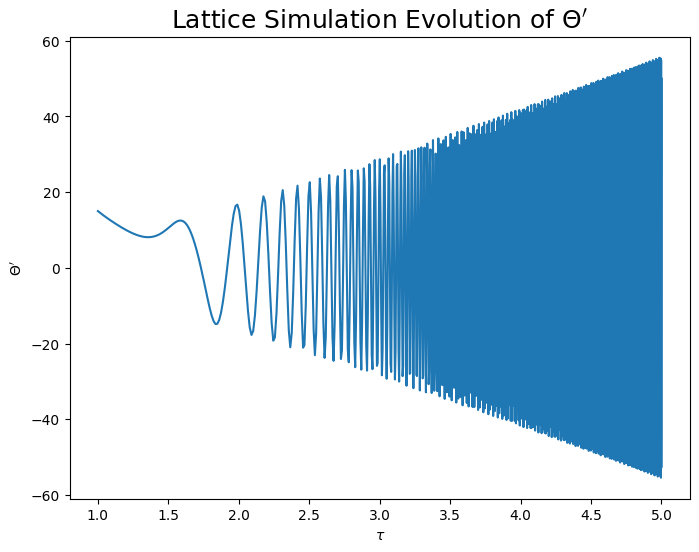

In [15]:
# Plot simulation evolution of θ'
plt.figure(figsize = (8, 6))
plt.plot(tautab_sim, vheta_avg)
plt.title(r"Lattice Simulation Evolution of $\Theta'$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Theta'$")
plt.show()

## Comparison

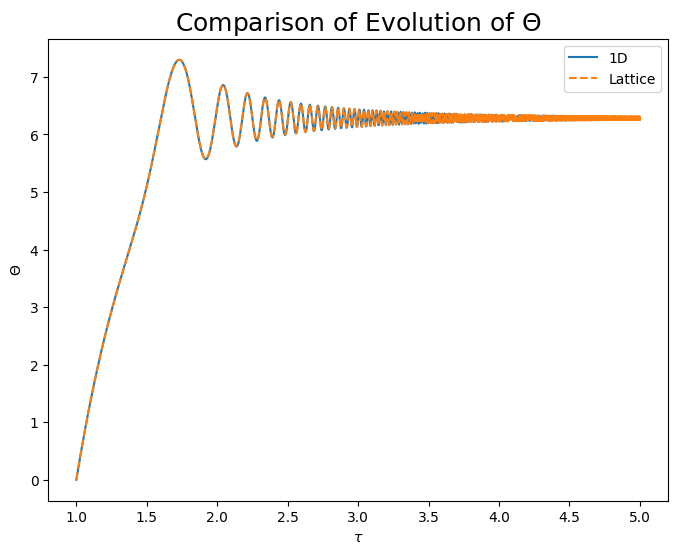

In [16]:
# Plot comparison of evolution of θ
plt.figure(figsize = (8, 6))
plt.plot(tautab, theta1D, label = '1D')
plt.plot(tautab_sim, theta_avg, label = 'Lattice', linestyle = '--')
plt.title(r"Comparison of Evolution of $\Theta$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Theta$')
plt.legend()
plt.show()

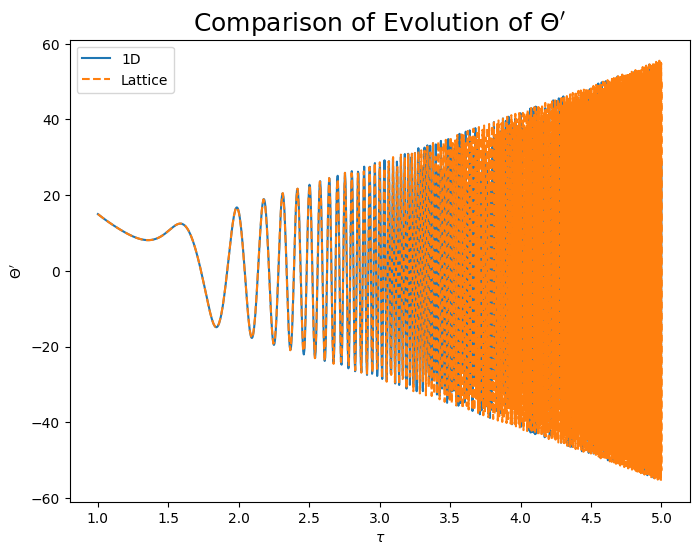

In [17]:
# Plot comparison of evolution of θ'
plt.figure(figsize = (8, 6))
plt.plot(tautab, vheta1D, label = '1D')
plt.plot(tautab_sim, vheta_avg, label = 'Lattice', linestyle = '--')
plt.title(r"Comparison of Evolution of $\Theta'$", fontsize = 18)
plt.xlabel(r'$\tau$')
plt.ylabel(r"$\Theta'$")
plt.legend()
plt.show()